# 04_概率分布-指数分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天来讲指数分布\~

指数分布（Exponential Distribution）是一种连续概率分布，通常用于描述随机事件之间的时间间隔。

例如，在一个公交站等候公交车、电话呼入中心等待电话、或粒子放射性衰变等场景中，我们常常关注两个连续事件之间间隔的时间，此时就可以利用指数分布来描述事件间等待时间的概率分布情况。

在数学建模中，指数分布与泊松过程（Poisson Process）密切相关。如果某一随机过程满足事件在固定时间内独立出现，且某段时间内的事件发生个数服从泊松分布，那么相邻事件之间的时间间隔就服从指数分布。

### 直观的一个例子

假设你正在一家快餐店排队结账，顾客到达收银台是随机发生的。如果我们假定顾客到达的过程没有任何周期性，并且每个顾客到达是独立发生的，那么顾客到达的数量在一定时间间隔内服从泊松分布。进一步地，两个顾客相继到达的时间间隔就可以用指数分布来建模。

再比如，在电话呼叫中心中，我们关心的是两个电话呼入之间的时间间隔。如果电话呼入是随机且独立的，那么这个时间间隔通常符合指数分布。

### 指数分布的本质与特点

#### 无记忆性

指数分布最显著的特点之一是“无记忆性”。

无记忆性意味着对于任意非负的时间 $s$和 $t$，有：


$$
P(X > s+t \mid X > s) = P(X > t)
$$


也就是说，给定已经等待了 $s$时间后，还需要等待额外 $t$时间的概率与刚开始等待 $t$时间的概率是一样的。这种性质在现实中也有直观的解释：比如公交车晚点，在已经等待了一段时间后，再等待同样额外时间的概率并不会因为已经等过而发生改变。

#### 单参数分布

指数分布只有一个参数，通常记为 $\lambda$（正参数），它代表了事件发生的速率。

参数 $\lambda$越大，意味着事件发生得越快，等待时间更短；反之，参数 $\lambda$越小，等待时间越长。

指数分布的概率密度函数（pdf）为：


$$
f(x; \lambda) = \lambda e^{-\lambda x}, \quad x \geq 0
$$


#### 平滑衰减的概率密度

从公式上看，指数分布的概率密度函数是一个随 $x$指数衰减的函数。也就是说，发生时间 $x$越长，概率密度值越小。直观上，这表明等待时间越长发生概率越低，这与很多现实中的等待时间问题相符。

#### 累积分布函数（CDF）

指数分布的累积分布函数定义为：


$$
F(x; \lambda) = 1 - e^{-\lambda x}, \quad x \geq 0
$$


它表示等待时间 $X$小于等于某个值 $x$的概率。这个函数从 0 开始，随着 $x$的增加逐渐接近 1。

## 公式推导

#### 从泊松过程到指数分布

假设某随机过程满足以下性质：

1. 某段时间内事件发生的次数服从泊松分布。
2. 相邻事件独立发生，事件在任意非重叠时间区间内的发生数目相互独立。

设单位时间内事件发生的平均次数为 $\lambda$（即事件发生的速率），那么在时间 $t$内发生 $k$次事件的概率为：


$$
P(N(t) = k) = \frac{(\lambda t)^k e^{-\lambda t}}{k!}, \quad k = 0,1,2,\ldots
$$


其中 $N(t)$表示在时间 $t$内发生的事件个数。

#### 等待时间的推导

令 $X$表示两次相邻事件之间的等待时间，我们希望找到 $X$的分布。

下面我们通过计算在时间 $t$内没有事件发生的概率来推导 $X$的累积分布函数。

**累积分布函数的推导**

由于事件发生服从泊松过程，在时间 $t$内没有发生任何事件的概率为：  
$P(N(t)=0)= e^{-\lambda t}$  
而这恰好就是等待时间大于 $t$的概率：  
$P(X > t)= e^{-\lambda t}$  
于是，等待时间 $X$的累积分布函数 $F(t)$为：  
$F(t) = P(X \leq t)= 1 - P(X > t)= 1- e^{-\lambda t}, \quad t \geq 0$  
这种推导直接显示了指数分布的累积性质。

**概率密度函数的推导**

接下来，我们求解概率密度函数。由累积分布函数的定义可知，概率密度函数 $f(t)$为其对 $t$求导：  
$f(t) = \frac{d}{dt}F(t) = \frac{d}{dt}\left(1- e^{-\lambda t}\right)= \lambda e^{-\lambda t}, \quad t \geq 0$  
从这里，我们得到了指数分布的标准形式。

#### 证明无记忆性

指数分布最神奇的性质在于其无记忆性。现证明对于任意 $s, t \geq 0$都有：  
$P(X > s+t \mid X > s)= P(X > t)$

证明过程如下：

1. 根据条件概率公式：  
$P(X > s+t \mid X > s)= \frac{P(X > s+t \cap X > s)}{P(X > s)}= \frac{P(X > s+t)}{P(X > s)}$  
注意到 $\{X > s+t\} \subset \{X > s\}$，故分子直接为 $P(X > s+t)$。
2. 利用前述结果：  
$P(X > s+t)= e^{-\lambda (s+t)},\quad P(X > s)= e^{-\lambda s}$  
则有：  
$P(X > s+t \mid X > s)= \frac{e^{-\lambda (s+t)}}{e^{-\lambda s}}= e^{-\lambda t}= P(X > t)$

这种推导严格验证了指数分布的无记忆性，在实际的概率建模中具有重要意义，因为它说明未来发生的概率与过去已经发生的时间无关。

#### 矩和方差推导

此外，我们还可以推导指数分布的期望和方差。

**期望**：期望 $E[X]$的计算公式为：


$$
E[X] = \int_0^{\infty} x f(x) \, dx= \int_0^{\infty} x \lambda e^{-\lambda x} \, dx
$$


利用积分公式：


$$
\int_0^{\infty} x e^{-\lambda x} \, dx = \frac{1}{\lambda^2}
$$


因此：


$$
E[X] = \lambda \cdot \frac{1}{\lambda^2}= \frac{1}{\lambda}
$$


**方差**：

方差的计算需要先计算二阶矩 $E[X^2]$：


$$
E[X^2]= \int_0^{\infty} x^2 \lambda e^{-\lambda x} \, dx
$$


有公式：


$$
\int_0^{\infty} x^2 e^{-\lambda x} \, dx= \frac{2}{\lambda^3}
$$


从而可得：


$$
E[X^2]= \lambda \cdot \frac{2}{\lambda^3}= \frac{2}{\lambda^2}
$$


方差 $Var(X)$为：


$$
Var(X)= E[X^2]- (E[X])^2= \frac{2}{\lambda^2}- \left(\frac{1}{\lambda}\right)^2= \frac{1}{\lambda^2}
$$


#### 总结推导过程

通过上述推导，我们可以总结出指数分布的一些核心公式：

- **累积分布函数（CDF）**：  
$F(x)= 1- e^{-\lambda x}, \quad x \geq 0$
- **概率密度函数（PDF）**：  
$f(x)= \lambda e^{-\lambda x}, \quad x \geq 0$
- **期望**：  
$E[X]= \frac{1}{\lambda}$
- **方差**：  
$Var(X)= \frac{1}{\lambda^2}$
- **无记忆性**：  
$P(X > s+t \mid X > s)= e^{-\lambda t}= P(X > t)$

这些结果不仅是数学上严格推导的结论，也完美地解释了指数分布在随机等待时间等实际问题中的合理性和应用价值。

## Python实现

在这一部分，我们将展示如何使用 Python 生成指数分布的数据以及如何对数据进行可视化。

同时，我们也会介绍一个机器学习算法应用的案例，展示如何利用指数分布辅助模型训练或数据特征提取。

### 生成指数分布数据

首先，我们将通过 NumPy 库生成随机的指数分布数据。

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 设定指数分布的参数 lambda（事件速率）
lambda_param = 1.0  # 参数值，这里采用1.0作为示例

# 生成随机数据，size 为样本大小
sample_size = 1000
data = np.random.exponential(scale=1/lambda_param, size=sample_size)

# 打印前10个数据以便查看
print("前10个随机数据：", data[:10])

前10个随机数据： [0.46926809 3.01012143 1.31674569 0.91294255 0.16962487 0.16959629
 0.05983877 2.01123086 0.91908215 1.23125006]


在上述代码中，使用 `np.random.exponential` 函数生成随机样本。其中 `scale` 参数正好是 $1/\lambda$，与公式 $E[X]=1/\lambda$对应。代码中生成了 1000 个样本，并打印了前 10 个数据作为查看。

### 数据分布的可视化

接下来，我们将绘制指数分布的概率密度函数和累积分布函数。

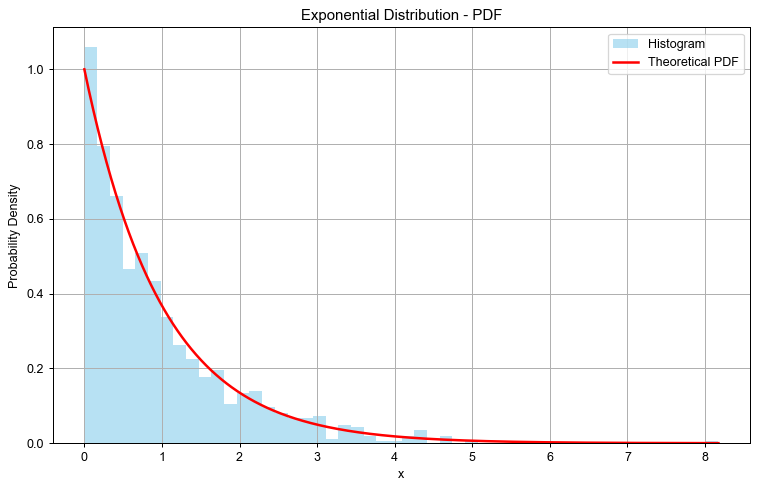

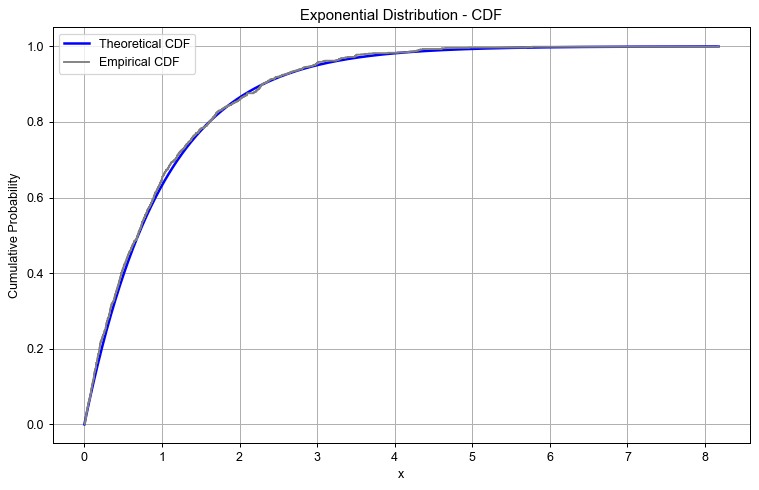

In [3]:
# 可视化概率密度函数（PDF）
plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(data, bins=50, density=True, alpha=0.6, color='skyblue', label='Histogram')

# 计算拟合的理论概率密度函数
x = np.linspace(0, np.max(data), 1000)
pdf = lambda_param * np.exp(-lambda_param * x)
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical PDF')

plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Exponential Distribution - PDF")
plt.legend()
plt.grid(True)
plt.show()

# 可视化累积分布函数（CDF）
cdf = 1 - np.exp(-lambda_param * x)
plt.figure(figsize=(10, 6))
plt.plot(x, cdf, 'b-', lw=2, label='Theoretical CDF')

# 经验累积分布函数：对样本数据排序，然后画出分布函数
sorted_data = np.sort(data)
yvals = np.arange(1, len(sorted_data)+1) / float(len(sorted_data))
plt.step(sorted_data, yvals, where='post', color='gray', label='Empirical CDF')

plt.xlabel("x")
plt.ylabel("Cumulative Probability")
plt.title("Exponential Distribution - CDF")
plt.legend()
plt.grid(True)
plt.show()

- **概率密度函数（PDF）**：我们首先使用直方图展示生成的数据分布情况，并归一化（参数 `density=True`），然后利用公式 $f(x)= \lambda e^{-\lambda x}$绘制理论的 PDF 曲线。通过两者的比较，可以直观验证样本数据是否符合指数分布。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

- **累积分布函数（CDF）**：对于 CDF，我们同样计算了理论值 $F(x)=1-e^{-\lambda x}$并绘制出来，同时利用样本数据生成经验 CDF（按照排序后的数据分别计算累计概率）。可以看到理论 CDF 和经验 CDF 非常吻合。

![原文参考图，当前结果见代码输出](attachments/img_021.png)

### 指数分布在机器学习中的应用

在机器学习中，指数分布常用于模拟等待时间、寿命预测、信号到达时间等场景。

下面给出一个简单的机器学习应用案例：利用指数分布生成样本数据，进而利用数据训练一个简单的回归模型预测某个连续变量（例如机器的故障时间）。

#### 机器学习应用背景

假设我们有一批设备，其故障（或失效）时间服从指数分布。我们希望通过设备运行时间作为特征，构建一个回归模型预测设备的剩余寿命。

#### 数据生成与特征构建

首先，利用指数分布生成模拟设备的故障时间数据，同时构造一些与故障时间相关的特征，例如工作温度、负载等（这里为了简化，假设只有设备运行时间一个特征）。

In [4]:
# 模拟设备的故障时间数据
np.random.seed(42)  # 固定随机种子，保证结果可复现
sample_size = 1000
lambda_param = 0.2  # 故障速率

# 设备运行时间（作为特征）和对应的故障时间（目标）
# 为了简单起见，这里假设运行时间与故障时间有关，但加入随机噪声模拟现实情况
X = np.random.exponential(scale=1/lambda_param, size=sample_size).reshape(-1, 1)
noise = np.random.normal(loc=0, scale=5, size=sample_size).reshape(-1, 1)
y = X + noise  # y 表示设备故障前的运行总时间

# 查看前 10 条数据
print("X（设备运行时间）前10个样本：", X[:10])
print("y（故障时间）前10个样本：", y[:10])

X（设备运行时间）前10个样本： [[ 2.34634045]
 [15.05060715]
 [ 6.58372847]
 [ 4.56471277]
 [ 0.84812435]
 [ 0.84798146]
 [ 0.29919384]
 [10.05615432]
 [ 4.59541077]
 [ 6.15625031]]
y（故障时间）前10个样本： [[ 3.23484545]
 [ 8.37388536]
 [ 8.48471772]
 [ 7.6176415 ]
 [ 3.64707659]
 [ 6.25188509]
 [ 4.46880462]
 [12.35205472]
 [ 4.24458221]
 [-2.14855436]]


#### 构建回归模型

我们采用 sklearn 库中的线性回归模型，基于运行时间 $X$预测故障时间 $y$。

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# 数据划分：70% 训练集，30% 测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 构建线性回归模型并训练
model = LinearRegression()
model.fit(X_train, y_train)

# 对测试集进行预测
y_pred = model.predict(X_test)

# 模型评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 22.540435890030416
R^2 Score: 0.4369623115601692


#### 模型结果与可视化展示

为了更直观地了解回归模型的表现，我们还将绘制散点图和回归直线。

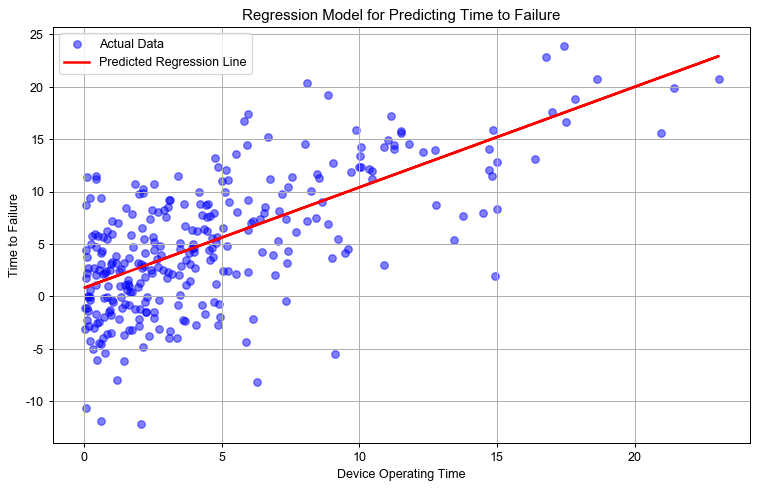

In [6]:
# 可视化测试集上的预测结果
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Regression Line')

plt.xlabel("Device Operating Time")
plt.ylabel("Time to Failure")
plt.title("Regression Model for Predicting Time to Failure")
plt.legend()
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_022.png)

我们利用指数分布生成了设备运行时间这一特征，并加入随机噪声模拟实际情况，构造了故障时间的数据。随后，通过线性回归模型，我们对设备的故障时间进行了预测。

尽管真实情况下设备的故障时间可能受多种因素影响，指数分布模型为故障时间提供了一种有效的统计描述，尤其在描述“无记忆性”的随机等待时间时，它有着天然的优势。

机器学习中，类似这种基于统计分布生成数据并结合回归、分类等模型的分析思路，可以辅助我们对一些先验已知满足特定分布的数据进行预测和异常检测。

到这里，大家通过本文的学习，你应该能够：

- 理解什么是指数分布以及其在随机等待时间问题中的实际意义；
- 掌握指数分布的核心公式和数学推导过程，尤其是无记忆性证明；
- 利用 Python 工具生成符合指数分布的数据，并通过数据可视化验证模型；
- 初步了解指数分布在机器学习（如预测设备故障时间、生存分析、异常检测等）中的应用。

指数分布虽然看似简单，但在工程、金融、通信、医学等多个领域都有着不可替代的重要作用。希望大家在今后的数据分析实践中能多多利用这些理论工具，可以为复杂问题提供简明的数学解释与解决方案。